In [1]:
import numpy as np
import pandas as pd
import statistics
import math as m

from sklearnex import patch_sklearn
patch_sklearn()

from modAL.models import ActiveLearner
from modAL.uncertainty import uncertainty_sampling

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from kmodes.kmodes import KModes
from sklearn import preprocessing

import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
np.random.seed(42)

data = pd.read_csv('dataset.csv')
data = data.drop(columns = ['Unnamed: 0','alpha_risk'])
data

,Q_1,Q_2,Q_3,Q_4,Q_5,Q_6,Q_7,Q_8,Q_9,Q_10,Q_11,Q_12,Q_13,Q_14,Q_15,risk_label,gender,age,sex_orient,immigrant
0,0,1,0,1,0,0,1,1,1,1,1,1,1,0,1,risky,1,4,0,0
1,0,0,0,1,1,1,0,1,0,0,1,1,0,1,0,risky,0,2,0,0
2,1,1,1,0,0,1,0,1,0,0,0,0,0,0,0,safe,1,1,0,0
3,0,1,0,0,0,1,0,1,0,0,1,0,0,0,0,safe,0,0,0,1
4,0,1,0,1,1,1,0,1,1,1,1,0,0,0,1,risky,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,0,1,1,1,1,0,0,1,1,1,0,1,1,1,risky,0,3,0,0
996,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,safe,0,2,0,0
997,1,1,0,1,1,0,0,0,1,1,0,1,0,0,1,safe,0,3,0,0
998,0,0,1,1,0,0,0,1,0,0,0,1,1,1,0,risky,0,4,1,1


In [3]:
X = data.drop(columns = ['risk_label'])
Y = data['risk_label']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y,test_size=0.2,random_state=42)

In [4]:
model = RandomForestClassifier(random_state=0)

model.fit(X_train,Y_train)

Y_pred = model.predict(X_test)

accuracy = len([i for i in range(len(Y_pred)) if Y_test.iloc[i] == Y_pred[i]])/len(Y_test.index)
print(f"Precisión final: {accuracy}")
pd.crosstab(Y_pred,Y_test)

Precisión final: 0.87


risk_label,risky,safe
row_0,,
risky,76,12
safe,14,98


In [5]:
stories = []

seeds = [10,20,30,40,50]


for s in seeds:
    np.random.seed(s)

    control_anot = [1]
    
    X = data.drop(columns = ['risk_label']).to_numpy()
    Y = data['risk_label'].to_numpy()
    
    X_train, X_pool, Y_train, Y_pool = train_test_split(X, Y,test_size=0.98,random_state=s)
    
    X_pool, X_test, Y_pool, Y_test = train_test_split(X_pool, Y_pool,test_size=0.2,random_state=s)
    
    learner = ActiveLearner(
        estimator=RandomForestClassifier(random_state=s),
        query_strategy=uncertainty_sampling,
        X_training=X_train, y_training=Y_train)
    
    unqueried_score = learner.score(X_test, Y_test)
    
    performance_history = [unqueried_score]
    
    for index in range(X_pool.shape[0]):
    
        uncertainty = learner.predict_proba(X_pool)
        max_uncertainty = np.max(uncertainty, axis=1)
    
        max_uncertainty = np.min(max_uncertainty)
        
        if max_uncertainty > 0.6:
            break
        
        query_index, query_instance = learner.query(X_pool)
    
        # Teach our ActiveLearner model the record it has requested.
        x,y = X_pool[query_index].reshape(1, -1), Y_pool[query_index].reshape(1, )
        learner.teach(X=x, y=y)
    
        # Remove the queried instance from the unlabeled pool.
        X_pool, Y_pool = np.delete(X_pool, query_index, axis=0), np.delete(Y_pool, query_index)
    
        # Calculate and report our model's accuracy.
        model_accuracy = learner.score(X_test, Y_test)
    
        # Save our model's performance for plotting.
        performance_history.append(model_accuracy)

    stories.append(performance_history)

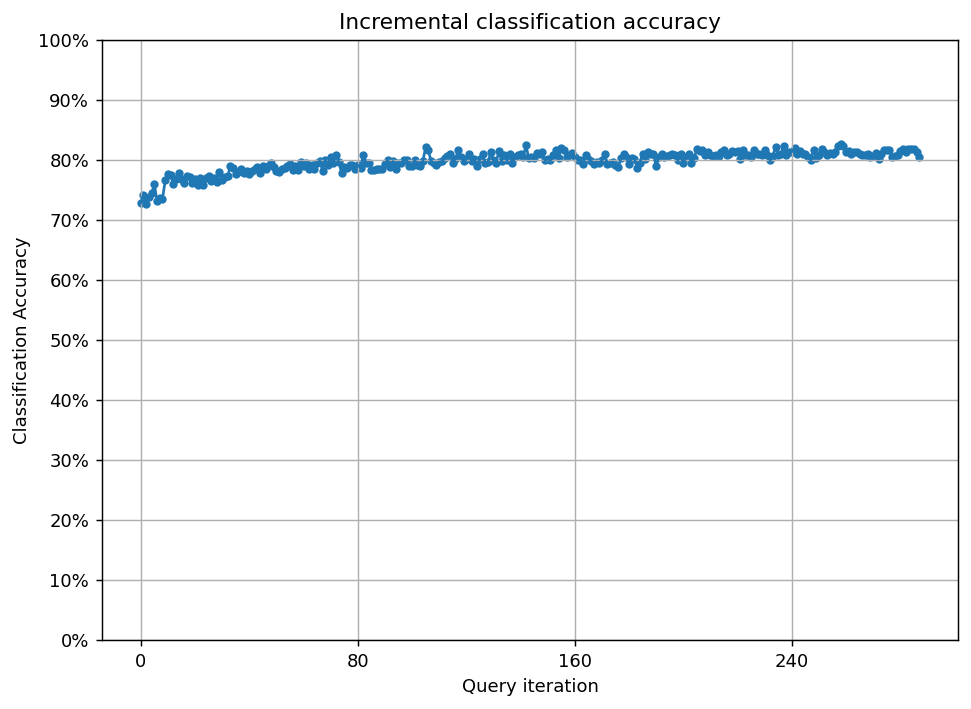

In [6]:
min_len = min(len(s) for s in stories)
stories = [s[:min_len] for s in stories]
med_stories = [np.mean(vals) for vals in zip(*stories)]

# Plot our performance over time.
fig, ax = plt.subplots(figsize=(8.5, 6), dpi=130)

ax.plot(med_stories)
ax.scatter(range(len(med_stories)), med_stories, s=13)

ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, integer=True))
ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=10))
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))

ax.set_ylim(bottom=0, top=1)
ax.grid(True)

ax.set_title('Incremental classification accuracy')
ax.set_xlabel('Query iteration')
ax.set_ylabel('Classification Accuracy')

plt.show()

In [7]:
print(f"Precisión final: {med_stories[-1]}")

Precisión final: 0.8051020408163264
